# OrthoSAM examples

## 5000x5000 pixel example from the Ravi River in the Northwest Himalaya

We are using the image Ravi1_Orthomosaic_5000x5000.jpg (9.7 MB). This was generated by resizing the original 0.2mm image with imagemagick:

```bash
magick Ravi1_Orthomosaic_0.2mm.jpg -resize 5000x5000 Ravi1_Orthomosaic_5000x5000.jpg
```

## Install OrthoSAM

You will need to activate the GPU environment within Google CoLab. Go to `Edit->Notebook settings` and chose the Hardware Settings `T4 GPU` (or any other GPUs if you have purchased additional computing resources). This will restart your kernel/notebook (but you only will need to do this once).

We are using the github repository and install all requirements from `OrthoSAM/requirements_colab.txt`. **Note that this will take a few minutes, because several NVIDIA CUDA libraries and extensions will have to be installed.**

## Setup Dependencies

In [1]:
!git clone https://github.com/UP-RS-ESP/OrthoSAM.git

Cloning into 'OrthoSAM'...
remote: Enumerating objects: 2372, done.
remote: Counting objects: 100% (149/149), done.
remote: Compressing objects: 100% (118/118), done.
remote: Total 2372 (delta 76), reused 74 (delta 31), pack-reused 2223 (from 2)
Receiving objects: 100% (2372/2372), 751.02 MiB | 27.05 MiB/s, done.
Resolving deltas: 100% (782/782), done.
Updating files: 100% (94/94), done.


In [1]:
!pip install -r OrthoSAM/requirements_colab.txt

  Using cached segment_anything-1.0-py3-none-any.whl


## Install OrthoSAM using the provided installer

In [4]:
!cd /content/OrthoSAM/OrthoSAM/
!pip install /content/OrthoSAM/ && orthosam-setup

Processing ./OrthoSAM
  Preparing metadata (setup.py) ... done
  Created wheel for OrthoSAM: filename=OrthoSAM-0.1-py3-none-any.whl size=44508 sha256=6a22783fbeca3c06c940852aa040fd28a8cb7bab2d307db4bd490bc90c613704
  Stored in directory: /tmp/pip-ephem-wheel-cache-mtcyyrqw/wheels/be/a9/4e/5df5140d8e9e9943e341505918600a63c4507c973b1c59685e
Successfully built OrthoSAM
Config file does not exist. Creating a new one at /usr/local/lib/python3.12/dist-packages/OrthoSAM/config.json
Config updated with base: /usr/local/lib/python3.12/dist-packages
OrthoSAM setup complete


Sometimes Google Colab is not downloading the required MetaSAM code - and you have to do it manually. This is often the case if you have not properly closed/shut down a Colab instance.

If you

In [6]:
!mkdir /content/OrthoSAM/OrthoSAM/MetaSAM
!wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
!mv sam_vit_h_4b8939.pth /content/OrthoSAM/OrthoSAM/MetaSAM

--2026-07-12 07:19:36--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 54.240.184.75, 54.240.184.45, 54.240.184.91, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|54.240.184.75|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2564550879 (2.4G) [binary/octet-stream]
Saving to: ‘sam_vit_h_4b8939.pth’

sam_vit_h_4b8939.pt 100%[===================>]   2.39G   239MB/s    in 16s     

2026-07-12 07:19:52 (155 MB/s) - ‘sam_vit_h_4b8939.pth’ saved [2564550879/2564550879]



# Use example Ravi1 image

In [7]:
!mkdir -p /content/OrthoSAM/data/Ravi1
#place file Ravi1_Orthomosaic_2000x2000.jpg into folder OrthoSAM/data/Ravi1


# Preparing OrthoSAM Config Files

In [8]:
cd /content/OrthoSAM

/content/OrthoSAM


In [9]:
import json
import os
import sys
from OrthoSAM.utility import load_config,create_dir_ifnotexist, prompt_fid,load_image, plot_tiling_with_overlap

In [10]:
from OrthoSAM.update_config import update_config_paths
update_config_paths('/content/OrthoSAM')

Config file does not exist. Creating a new one at /content/OrthoSAM/OrthoSAM/config.json
Config updated with base: /content/OrthoSAM
Config updated with base: /content/OrthoSAM


We have downloaded one image into `/content/OrthoSAM/data/Ravi1` and will use this image as a segmentation example. If you have multiple images in that directory, you can process all of them in one run. The image to be processed is controlled by the `id` parameter. Here, we set it to `id=0` to only use the first image.

If you set `id=None`, all files in the directory listed in 'DatasetName' will be processed.

In [11]:
id=0 # Filename or the index after sorting by file name. If not known input None and all files will be listed with the index.
# For this example, we only work with the first image (id=0).

#main_para defines the parameters for the first layer
#it also serves as a template for the later layers.
main_para={'OutDIR': f'Ravi1/Ravi1_{id}_up2_org',# where output will be stored relative to the MainOutDIR stored in config.json
    'DatasetName': 'Ravi1',#where image is stored
    'fid': id, #Filename or the index after sorting by file name. If index is not known use None and all files will be listed with the index.
    'resolution(mm)': 1, #image resolution in mm/pixel
    'tile_size': 1024,
    'tile_overlap':200,
    'resample_factor': 1, #'Auto': auto select resample rate.
    'input_point_per_axis': 30,
    'dilation_size':5,
    'stability_t':0.85,
    'expected_min_size(sqmm)': 50,
    'min_radius': 0,
    'Calculate_stats': True, # True: calculate statistics.
    'Discord_notification': False,# True: send discord when finished. If you wish to use this feature, please create a file name DWH.txt in the code directory and set the webhook.
    'Plotting': True# True: plot the results
    }

#para_list defines the parameters for the later layers
#each dictionary corresponds to one layer.
# The first layer is defined in main_para.
#the second layer is defined in para_list[0] and so on.
#main_para serves as a template for the later layers.
#and in para_list specify the parameters for each layer that need to be updated.
# para_list = []
para_list=[
    {'resample_factor':1/2,
    }
    ]

#parameters for preprocessing. Only create this list if you want to use preprocessing.
#preprocessing is optional.
pre_para_list=[{#'Gaussian': {'kernel size':3},
                #'CLAHE':{'clip limit':2},
                #'Resample': {'fxy':4},
                #'Buffering': {'crop size': crop_size}
            },{},{}]

You can verify the parameters by looking at the dictonaries

In [15]:
main_para

{'MODEL_TYPE': 'vit_h',
 'CheckpointDIR': '/content/OrthoSAM/OrthoSAM/MetaSAM',
 'DataDIR': '/content/OrthoSAM/data',
 'MainOutDIR': '/content/OrthoSAM/output',
 'BaseDIR': '/content/OrthoSAM',
 'OutDIR': '/content/OrthoSAM/output/Ravi1/Ravi1_0_up2_org',
 'DatasetName': 'Ravi1',
 'fid': 0,
 'resolution(mm)': 1,
 'tile_size': 1024,
 'tile_overlap': 200,
 'resample_factor': 1,
 'input_point_per_axis': 30,
 'dilation_size': 5,
 'stability_t': 0.85,
 'expected_min_size(sqmm)': 50,
 'min_radius': 0,
 'Calculate_stats': True,
 'Discord_notification': False,
 'Plotting': True,
 '1st_resample_factor': 1}

In [16]:
main_para['1st_resample_factor'] = main_para['resample_factor']
config = load_config()
main_para={**config,**main_para}
main_para['OutDIR'] = os.path.join(main_para.get('MainOutDIR'), main_para.get('OutDIR'))
if not os.path.exists(os.path.join(main_para.get('DataDIR'), main_para.get('DatasetName'))):
    print('Input directory does not exist. Exiting script.')
    sys.exit()

OutDIR=main_para.get('OutDIR')
create_dir_ifnotexist(OutDIR)

/content/OrthoSAM/data/Ravi1/Ravi1_Orthomosaic_2000x2000.jpg imported


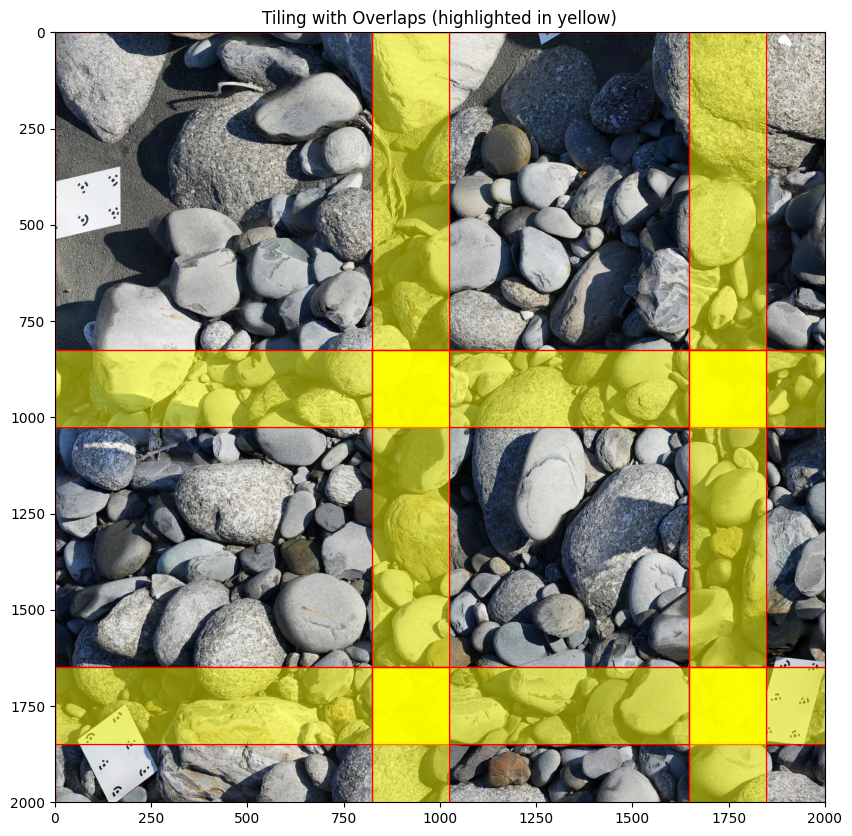

In [17]:
import matplotlib.pyplot as plt
DataDIR = main_para.get('DataDIR')
DSname = main_para.get('DatasetName')
fid = main_para.get('fid')
crop_size = main_para.get('tile_size')
overlap = main_para.get('tile_overlap')
image=load_image(DataDIR,DSname,fid)

plt.figure(figsize=(15,10))
plot_tiling_with_overlap(image, (crop_size,crop_size), overlap)

In [18]:
# Save init_para to a JSON file
para_list.insert(0, {})
pass_para_list = [dict(main_para, **para) for para in para_list]
with open(OutDIR+f'init_para.json', 'w') as json_file:
    json.dump(pass_para_list, json_file, indent=4)
with open(OutDIR+f'pre_para.json', 'w') as json_file:
    json.dump(pre_para_list, json_file, indent=4)

# Run the OrthoSAM analysis



In [19]:
from OrthoSAM import orthosam
orthosam(pass_para_list)

Output hidden; open in https://colab.research.google.com to view.

# Verify results and plot

Here we do some first-oder analysis of the output statistic data.

In [20]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

merged_results = pd.read_csv('/content/OrthoSAM/output/Ravi1/Ravi1_0_up2_org/props.csv')

In [ ]:
merged_results.head()

,label,centroid-0,centroid-1,axis_major_length,axis_minor_length,area,perimeter,IR,h,IRt,IRn,mean_R,mean_G,mean_B,median_R,median_G,median_B
0,1,51.447151,442.729894,110.446314,101.913859,8704.0,355.220346,0.866828,0.001614,0.997580,0.868931,182.592486,144.814453,96.842371,184.0,137.0,87.0
1,2,35.941292,1807.150685,51.654952,27.867122,1022.0,146.024387,0.602296,0.089482,0.870890,0.691587,113.761252,100.433464,80.425636,116.0,103.5,84.0
2,3,84.988431,169.490051,117.171667,94.528627,8644.0,355.303607,0.860450,0.011440,0.982926,0.875396,150.280773,134.250810,106.088385,153.0,136.0,106.0
3,4,56.149029,626.274890,51.854418,49.120602,1597.0,188.610173,0.564137,0.000733,0.998901,0.564758,163.501565,165.520351,144.077019,169.0,174.0,153.0
4,5,62.279221,1766.721320,71.525998,38.786690,1848.0,202.551299,0.566033,0.088082,0.872833,0.648501,91.094156,77.805736,59.996212,91.0,78.0,59.0


In [21]:
len(merged_results)

490

In [22]:
merged_results.describe()

,label,centroid-0,centroid-1,axis_major_length,axis_minor_length,area,perimeter,IR,h,IRt,IRn,mean_R,mean_G,mean_B,median_R,median_G,median_B
count,490.00000,490.000000,490.000000,490.000000,490.000000,490.000000,490.000000,490.000000,490.000000,490.000000,490.000000,490.000000,490.000000,490.000000,490.000000,490.000000,490.000000
mean,245.50000,1145.632555,1089.208145,90.336440,55.632416,5801.759184,258.297705,0.693858,0.091193,0.874508,0.806732,78.912842,82.219347,85.581815,78.715306,82.262245,85.965306
std,141.59508,508.772895,552.534496,65.177994,46.707475,10374.988994,197.012791,0.174500,0.102872,0.130644,0.393773,52.405894,50.888790,48.062631,61.992538,59.664357,55.366328
min,1.00000,22.318713,31.460000,8.132603,1.166519,8.000000,6.414214,0.206354,0.000024,0.252458,0.270204,2.091133,2.985222,5.098246,2.000000,3.000000,4.000000
25%,123.25000,772.723946,655.635793,47.805657,24.207620,862.000000,129.214989,0.596823,0.020306,0.828333,0.729706,28.072033,34.968824,42.530587,24.000000,30.000000,39.000000
50%,245.50000,1110.539879,1116.093498,69.367461,38.901376,1956.500000,194.045202,0.712327,0.052284,0.923339,0.798467,74.227497,78.469496,81.757858,54.250000,59.000000,69.500000
75%,367.75000,1624.311270,1584.400974,116.457811,71.657831,5837.250000,333.662734,0.805240,0.120576,0.969811,0.857353,120.157899,121.538323,121.505160,135.000000,131.750000,130.125000
max,490.00000,1966.261905,1959.411523,433.465532,317.329213,78243.000000,1286.330086,2.443504,0.653494,0.999964,7.314254,250.333333,250.160819,249.201754,255.000000,255.000000,255.000000


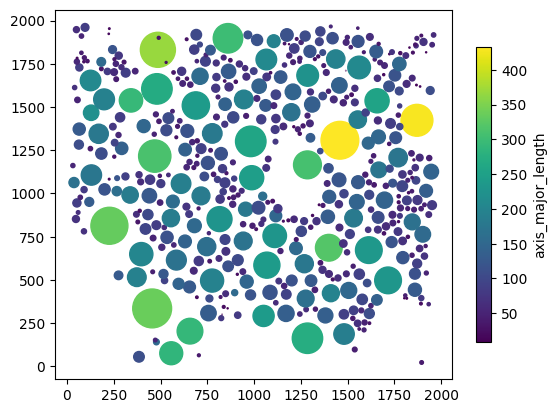

In [23]:
plt.scatter(merged_results['centroid-1'],
            merged_results['centroid-0'],
            c=merged_results['axis_major_length'],
            s=merged_results['area']/100,
            cmap='viridis')
h = plt.colorbar(shrink=0.8)
h.set_label('axis_major_length')

## Loading labeled images

In [24]:
merged_img = np.load('/content/OrthoSAM/output/Ravi1/Ravi1_0_up2_org/Merged/Merged_Layers_001.npy')

In [25]:
merged_img

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(2000, 2000))

In [26]:
#convert to float and then set background to nan
merged_img = merged_img.astype(np.float32)

In [27]:
merged_img[merged_img == 0.0] = np.nan

In [28]:
len(np.unique(merged_img[~np.isnan(merged_img)]))

491

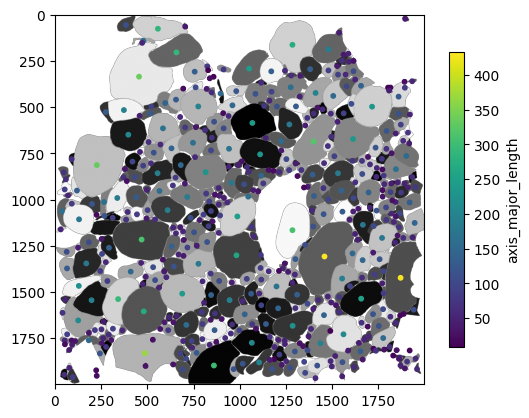

In [29]:
vals = np.linspace(0,1,256)
np.random.shuffle(vals)
cmap = plt.cm.colors.ListedColormap(plt.cm.gray(vals))
plt.imshow(merged_img, cmap=cmap)

plt.scatter(merged_results['centroid-1'], merged_results['centroid-0'], c=merged_results['axis_major_length'], s=10, cmap='viridis')
h = plt.colorbar(shrink=0.8)
h.set_label('axis_major_length')

In [46]:
fig, axs = plt.subplots(1, 2, layout='constrained', figsize=(16, 8), dpi=300)

#Left figure:
image_fn='/content/OrthoSAM/data/Ravi1/Ravi1_Orthomosaic_2000x2000.jpg'
from PIL import Image
with Image.open(image_fn) as image:
    image.load()  # Explicitly forces the image data to load into memory
img = np.asarray(image)
axs[0].imshow(img)
axs[0].scatter(merged_results['centroid-1'], merged_results['centroid-0'], c=merged_results['axis_major_length'], s=10, cmap='viridis')

#Right figure:
vals = np.linspace(0,1,256)
np.random.shuffle(vals)
cmap = plt.cm.colors.ListedColormap(plt.cm.gray(vals))
axs[1].imshow(merged_img, cmap=cmap)

sct1 = axs[1].scatter(merged_results['centroid-1'], merged_results['centroid-0'], c=merged_results['axis_major_length'], s=10, cmap='viridis')
h = plt.colorbar(sct1, shrink=0.8)
h.set_label('axis_major_length')

fig.suptitle('Ravi1 OrthoSAM Results', fontsize=16)
fig.savefig('Ravi1_OrthoSAM_results.jpg')

Output hidden; open in https://colab.research.google.com to view.

## Filter out pebbles with a roundness metric (isoperimetric ratio)

There are different ways to remove objects from the database that are no pebbles. You can do this manually by looking at the labelled images (see next point) - but this will be tidious when there are many pebbles. In this example, we rely on a roundness factor (see relevant publications cited in the main manuscript, including Cox, 1927; Pokhrel et al., 2024; Roussillon et al., 2009. The isoperimetric ratio is defined as the ratio of the area in 2D to its perimeter. This metric is dependent on the shape of the pebble, and hence a normalized isoperimetric ratio (IRn) has been developed that removes (partly) a shape dependence. The IRn is the isoperimetric ratio divided by a maximum theoretical isoperimetric ratio (IRt).

In our output database, we provide all variants of the  isoperimetric ratio. For example, we can color each centroid by its IRn:

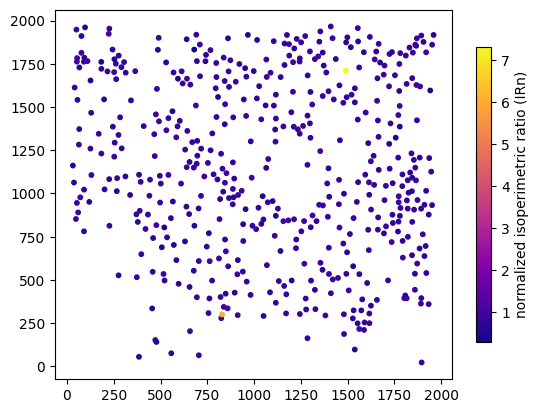

In [30]:
plt.scatter(merged_results['centroid-1'], merged_results['centroid-0'], c=merged_results['IRn'], s=10, cmap='plasma')
h = plt.colorbar(shrink=0.8)
h.set_label('normalized isoperimetric ratio (IRn)')

In [31]:
merged_results[merged_results['IRn'] < 0.49]

,label,centroid-0,centroid-1,axis_major_length,axis_minor_length,area,perimeter,IR,h,IRt,IRn,mean_R,mean_G,mean_B,median_R,median_G,median_B
8,9,140.983452,477.906619,151.491527,31.500809,1692.0,320.994949,0.206354,0.429961,0.462027,0.446629,160.099291,158.204492,151.618203,189.0,186.0,175.0
137,138,803.696058,519.935685,59.737937,32.604390,964.0,176.024387,0.390968,0.086340,0.875255,0.446691,20.364108,22.240664,23.965768,14.0,16.0,18.0
354,355,1595.911970,1941.324889,108.392874,56.365240,3158.0,345.421356,0.332601,0.099718,0.856752,0.388211,9.050982,10.381254,11.981951,9.0,11.0,12.0
379,380,1664.098214,592.973214,40.328778,22.585605,560.0,130.225397,0.414960,0.079536,0.884748,0.469015,19.253571,19.408929,19.385714,14.0,14.0,15.0
416,417,1761.466148,183.158236,154.336768,54.505103,3855.0,386.646753,0.324045,0.228508,0.689231,0.470155,108.643061,108.623606,105.606226,111.0,109.0,105.0
444,445,1832.582795,680.040129,86.488913,80.149521,4336.0,441.410209,0.279650,0.001447,0.997830,0.280258,166.645987,167.185194,169.135148,189.0,189.0,189.0
455,456,1846.543210,1516.839506,49.414786,21.300935,567.0,140.124892,0.362879,0.158055,0.778544,0.466100,15.047619,17.398589,17.171076,15.0,17.0,17.0
459,460,1854.431638,1865.829379,67.225715,33.058414,885.0,222.095454,0.225462,0.116080,0.834415,0.270204,23.124294,26.436158,30.578531,23.0,27.0,31.0


In [32]:
merged_img_IRn045 = np.empty_like(merged_img)
merged_img_IRn045.fill(np.nan)
IRn045_df = merged_results[merged_results['IRn'] < 0.5]

for i in range(len(IRn045_df)):
    merged_img_IRn045[merged_img == IRn045_df.iloc[i]['label']] = IRn045_df.iloc[i]['label']

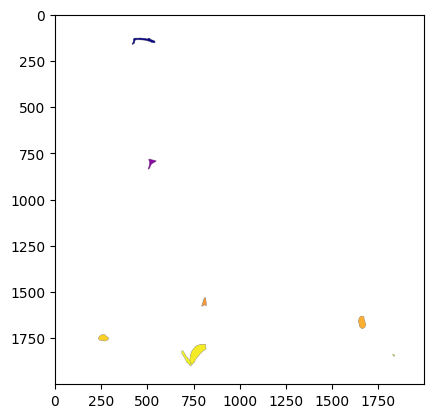

In [33]:
plt.imshow(merged_img_IRn045, cmap='plasma')

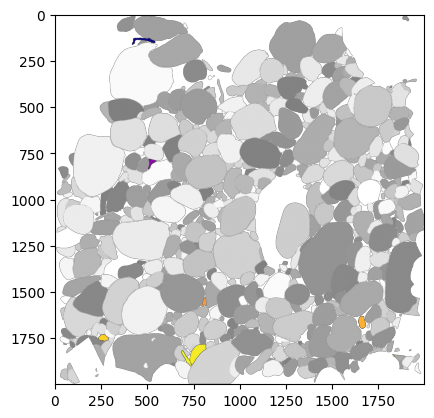

In [34]:
vals = np.linspace(0.5,1,256)
np.random.shuffle(vals)
cmap = plt.cm.colors.ListedColormap(plt.cm.gray(vals))
plt.imshow(merged_img, cmap=cmap)

plt.imshow(merged_img_IRn045, cmap='plasma')

## Plot size distribution

In [35]:
IRnabove05_df = merged_results[merged_results['IRn'] >= 0.5]
print(len(IRnabove05_df))
IRnabove05_df.head()

482


,label,centroid-0,centroid-1,axis_major_length,axis_minor_length,area,perimeter,IR,h,IRt,IRn,mean_R,mean_G,mean_B,median_R,median_G,median_B
0,1,55.168041,384.691065,110.906014,70.106348,5820.0,350.296465,0.596021,0.050804,0.925462,0.644025,61.317182,73.734192,89.257216,40.0,55.0,76.0
1,2,22.318713,1895.327485,39.114143,23.972327,684.0,107.639610,0.741860,0.057608,0.915728,0.810131,250.333333,250.160819,249.201754,255.0,255.0,255.0
2,3,75.717009,557.193218,286.316429,124.067848,27280.0,772.695526,0.574166,0.156308,0.780830,0.735328,95.091239,98.901466,104.542375,96.0,98.0,102.0
3,4,162.517562,1285.208486,272.950368,230.837580,47917.0,907.092496,0.731807,0.006988,0.989550,0.739534,48.537346,59.772523,73.444289,45.0,57.0,71.0
4,5,63.976581,704.772834,36.729939,15.421550,427.0,90.325902,0.657678,0.166943,0.766974,0.857497,20.714286,31.925059,51.388759,20.0,31.0,51.0


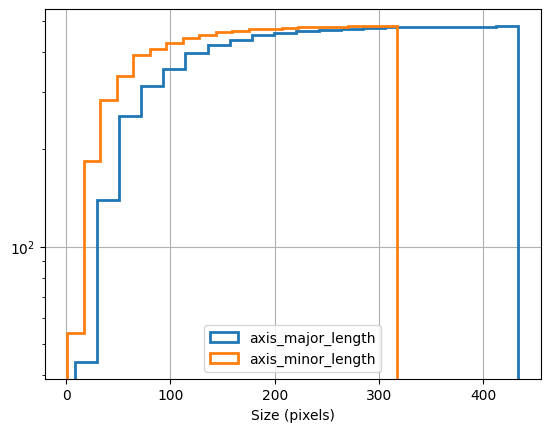

In [36]:
IRnabove05_df.axis_major_length.hist(bins = 20, log = True, cumulative=True, alpha=1, label='axis_major_length', histtype='step', linewidth=2) #density=True
IRnabove05_df.axis_minor_length.hist(bins = 20, log = True, cumulative=True, alpha=1, label='axis_minor_length', histtype='step', linewidth=2) #density=True
plt.xlabel('Size (pixels)')
plt.legend()